# Lab 2 Microwave Optics
### Plots for each experiment below: 

In [1]:
########## NECESSARY IMPORTS ##########
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set global plot style for clean IEEE-style graphs
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12

## Experiment 1: Angular Beam Spread

--- Part 1: Angular Beam Spread ---


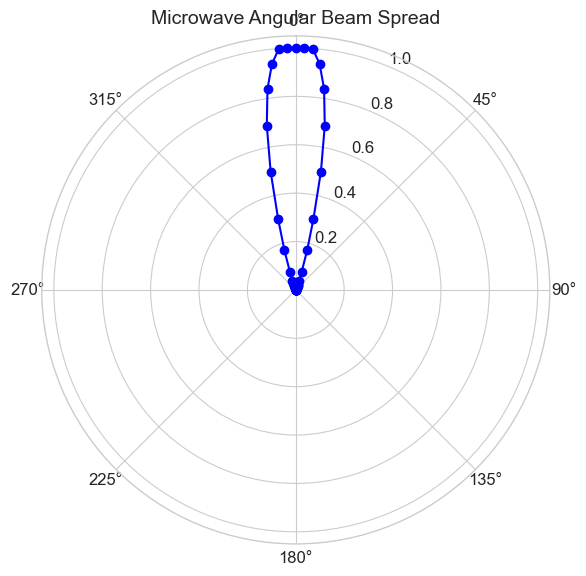

Calculated FWHM: 24 degrees



In [2]:
# ==========================================
# PART 1: ANGULAR BEAM SPREAD
# ==========================================
print("--- Part 1: Angular Beam Spread ---")
df_beam = pd.read_csv('Lab_2_Experiment_1_data.csv')
df_beam = df_beam.dropna(subset=['Signal_reading']) # Drop rows without measurements

# Convert to radians for polar plot
angles_rad = np.radians(df_beam['Angle_deg'])
signal = df_beam['Signal_reading']

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
ax.plot(angles_rad, signal, marker='o', linestyle='-', color='b')
ax.set_theta_zero_location("N") # 0 degrees at the top
ax.set_theta_direction(-1)      # Clockwise
ax.set_title("Microwave Angular Beam Spread", va='bottom', fontsize=14)
plt.tight_layout()
plt.show()

# Calculate FWHM (Full-Width at Half-Maximum)
# Finding where the signal is closest to 0.5 on the left and right
left_side = df_beam[df_beam['Angle_deg'] < 0]
right_side = df_beam[df_beam['Angle_deg'] > 0]

# Get angles where signal is approximately 0.5
angle_left = left_side.iloc[(left_side['Signal_reading'] - 0.5).abs().argmin()]['Angle_deg']
angle_right = right_side.iloc[(right_side['Signal_reading'] - 0.5).abs().argmin()]['Angle_deg']
fwhm = angle_right - angle_left
print(f"Calculated FWHM: {fwhm} degrees\n")

## Experiment 2: Standing Waves

--- Part 2: Standing Waves ---
Measured Wavelength: 2.800 cm
Theoretical Wavelength: 2.850 cm
Percent Error: 1.77%



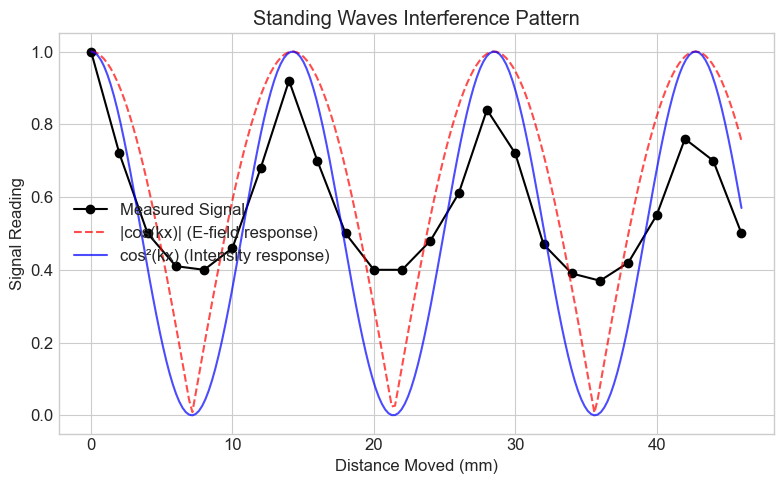

In [3]:
# ==========================================
# PART 2: STANDING WAVES
# ==========================================
print("--- Part 2: Standing Waves ---")
df_sw = pd.read_csv('Lab_2_StandingWaves_data.csv')
# Clean column names to avoid whitespace issues
df_sw.columns = [col.strip() for col in df_sw.columns]

dist_mm = df_sw['Distance Moved (mm)']
signal_sw = df_sw['Signal Reading (units)']

# Find peaks (approximate distances: 0, 14, 28, 42 mm)
# The spacing between adjacent maxima is lambda / 2
peak_spacing_mm = 14.0 
lambda_measured_cm = (peak_spacing_mm * 2) / 10 # convert mm to cm

f = 10.525e9 # Hz
c = 3e10     # cm/s
lambda_theory_cm = c / f

error = abs(lambda_measured_cm - lambda_theory_cm) / lambda_theory_cm * 100

print(f"Measured Wavelength: {lambda_measured_cm:.3f} cm")
print(f"Theoretical Wavelength: {lambda_theory_cm:.3f} cm")
print(f"Percent Error: {error:.2f}%\n")

# Plot Standing Waves Data vs Theory
# We normalize the distance so we can plot idealized cos(kx) and cos^2(kx)
x_theory = np.linspace(0, max(dist_mm), 200)
k = 2 * np.pi / (lambda_theory_cm * 10) # use theory lambda in mm

plt.figure(figsize=(8, 5))
plt.plot(dist_mm, signal_sw, 'ko-', label='Measured Signal')
# Scale theoretical curves to match the max signal amplitude (1.0)
plt.plot(x_theory, np.abs(np.cos(k * x_theory)), 'r--', alpha=0.7, label='|cos(kx)| (E-field response)')
plt.plot(x_theory, np.cos(k * x_theory)**2, 'b-', alpha=0.7, label='cos²(kx) (Intensity response)')
plt.xlabel("Distance Moved (mm)")
plt.ylabel("Signal Reading")
plt.title("Standing Waves Interference Pattern")
plt.legend()
plt.tight_layout()
plt.show()

## Experiment 3: Polarization

--- Part 3: Polarization ---


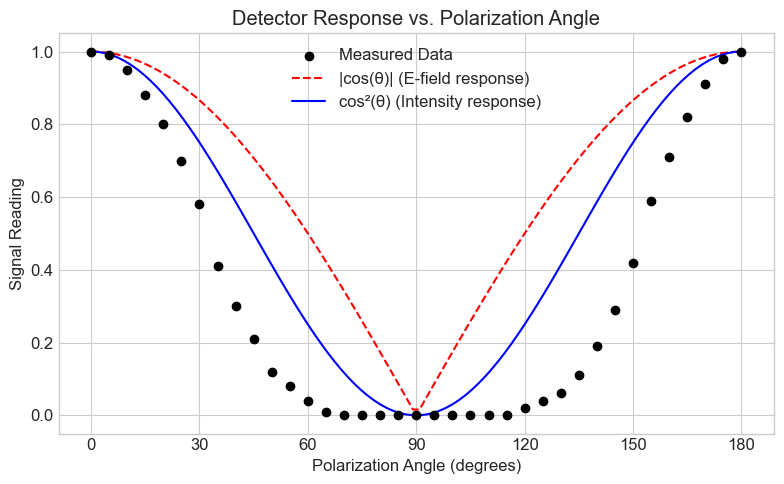

In [4]:
# ==========================================
# PART 3: POLARIZATION
# ==========================================
print("--- Part 3: Polarization ---")
df_pol = pd.read_csv('Lab_2_Polarization_data.csv')
df_pol.columns = [col.strip() for col in df_pol.columns]

theta_deg = df_pol['Angle (degrees)']
signal_pol = df_pol['Signal reading (mA)']
theta_rad = np.radians(theta_deg)

# Generate theoretical curves
theta_theory = np.linspace(0, np.pi, 100)
cos_theta = np.abs(np.cos(theta_theory))
cos_squared_theta = np.cos(theta_theory)**2

plt.figure(figsize=(8, 5))
plt.scatter(theta_deg, signal_pol, color='black', zorder=5, label='Measured Data')
plt.plot(np.degrees(theta_theory), cos_theta, 'r--', label='|cos(θ)| (E-field response)')
plt.plot(np.degrees(theta_theory), cos_squared_theta, 'b-', label='cos²(θ) (Intensity response)')
plt.xlabel("Polarization Angle (degrees)")
plt.ylabel("Signal Reading")
plt.title("Detector Response vs. Polarization Angle")
plt.xticks(np.arange(0, 181, 30))
plt.legend()
plt.tight_layout()
plt.show()

## Experiment 4: Reflection

--- Part 4: Reflection ---


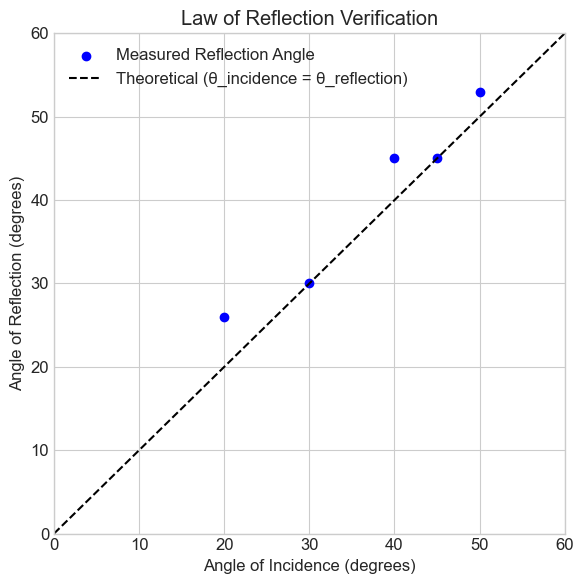

In [5]:
# ==========================================
# PART 4: REFLECTION
# ==========================================
print("--- Part 4: Reflection ---")
df_reflec = pd.read_csv('Lab_2_Reflection_data.csv')
df_reflec.columns = [col.strip() for col in df_reflec.columns]

# Drop rows with no conclusive results
df_reflec = df_reflec.dropna(subset=['Angle of Reflection (deg)'])

angle_in = df_reflec['Angle of Incidence (deg)']
angle_out = df_reflec['Angle of Reflection (deg)']

plt.figure(figsize=(6, 6))
plt.scatter(angle_in, angle_out, color='b', label='Measured Reflection Angle')
# Plot ideal y=x line
plt.plot([0, 60], [0, 60], 'k--', label='Theoretical (θ_incidence = θ_reflection)')
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.xlabel("Angle of Incidence (degrees)")
plt.ylabel("Angle of Reflection (degrees)")
plt.title("Law of Reflection Verification")
plt.legend()
plt.tight_layout()
plt.show()

## Experiment 5: Refraction

In [6]:
# ==========================================
# PART 5: REFRACTION (CALCULATIONS ONLY)
# ==========================================
print("--- Part 5: Refraction ---")
# From the user's Lab_2_Refraction_data.csv:
theta_1_deg = 20.0
theta_measured_deg = 19.0

# Geometry gives: theta_2 = theta_1 + measured_theta
theta_2_deg = theta_1_deg + theta_measured_deg

# Convert to radians for math
theta_1_rad = np.radians(theta_1_deg)
theta_2_rad = np.radians(theta_2_deg)

# Snell's Law: n1 * sin(theta_1) = n2 * sin(theta_2)
# Assume n2 (air) = 1.0
n2 = 1.0
n1 = (n2 * np.sin(theta_2_rad)) / np.sin(theta_1_rad)

print(f"Prism Angle (θ1): {theta_1_deg} degrees")
print(f"Deflection Angle (θ): {theta_measured_deg} degrees")
print(f"Refracted Angle (θ2): {theta_2_deg} degrees")
print(f"Calculated Index of Refraction for Styrene (n): {n1:.3f}")

--- Part 5: Refraction ---
Prism Angle (θ1): 20.0 degrees
Deflection Angle (θ): 19.0 degrees
Refracted Angle (θ2): 39.0 degrees
Calculated Index of Refraction for Styrene (n): 1.840
